# Lab 17: Extract Patterns Using Regular Expressions
## Objectives

By the end of this lab, students will be able to:

• Understand the fundamentals of regular expressions (regex) and their applications in data cleaning  
• Use Python's str.extract() method with regex patterns to extract specific information from messy text data  
• Apply regex replacement techniques to clean and standardize address and ID fields  
• Extract date components (specifically years) from various date string formats  
• Implement practical data cleaning solutions for real-world healthcare data scenarios

## Prerequisites

Before starting this lab, students should have:

• Basic understanding of Python programming concepts (variables, strings, functions)  
• Familiarity with pandas DataFrames and basic data manipulation  
• Knowledge of string operations in Python  
• Understanding of data types and basic data structures  
• Access to a Python environment with pandas library installed

In [1]:
import pandas as pd
import re
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Environment setup complete!")

Environment setup complete!


In [2]:
patient_data = {
    'record_id': [1,2,3,4,5,6,7,8],
    'patient_info': [
        'Patient: John Smith, Age: 45, Phone: (555) 123-4567',
        'Name: Mary Johnson Age:32 Phone:(555)987-6543',
        'Patient Name: Robert Brown, Age: 28, Contact: 555.456.7890',
        'John Doe - Age 55 - Phone Number: (555) 234-5678',
        'Patient: Sarah Wilson, Age: 41, Tel: 555-789-0123',
        'Name: Michael Davis Age:37 Phone:(555)345-6789',
        'Patient: Lisa Anderson, Age: 29, Phone: (555) 567-8901',
        'David Miller - Age 63 - Contact: 555.678.9012'
    ]
}

df_patients = pd.DataFrame(patient_data)

print(df_patients)

   record_id                                       patient_info
0          1  Patient: John Smith, Age: 45, Phone: (555) 123...
1          2      Name: Mary Johnson Age:32 Phone:(555)987-6543
2          3  Patient Name: Robert Brown, Age: 28, Contact: ...
3          4   John Doe - Age 55 - Phone Number: (555) 234-5678
4          5  Patient: Sarah Wilson, Age: 41, Tel: 555-789-0123
5          6     Name: Michael Davis Age:37 Phone:(555)345-6789
6          7  Patient: Lisa Anderson, Age: 29, Phone: (555) ...
7          8      David Miller - Age 63 - Contact: 555.678.9012


In [3]:
name_pattern = r'(?:Patient:|Name:|Patient Name:)\s*([A-Za-z\s]+?)(?:,|\s-\sAge|\sAge)'

df_patients['patient_name'] = df_patients['patient_info'].str.extract(name_pattern)

print(df_patients[['record_id','patient_name']])

   record_id   patient_name
0          1     John Smith
1          2   Mary Johnson
2          3   Robert Brown
3          4            NaN
4          5   Sarah Wilson
5          6  Michael Davis
6          7  Lisa Anderson
7          8            NaN


In [4]:
age_pattern = r'Age:?\s*(\d+)'

df_patients['age'] = df_patients['patient_info'].str.extract(age_pattern)

df_patients['age'] = pd.to_numeric(df_patients['age'])

print(df_patients[['record_id','patient_name','age']])

   record_id   patient_name  age
0          1     John Smith   45
1          2   Mary Johnson   32
2          3   Robert Brown   28
3          4            NaN   55
4          5   Sarah Wilson   41
5          6  Michael Davis   37
6          7  Lisa Anderson   29
7          8            NaN   63


In [5]:
phone_pattern = r'(?:Phone:|Tel:|Contact:|Phone Number:)\s*(\(?[\d]{3}\)?[-.\s]?[\d]{3}[-.\s]?[\d]{4})'

df_patients['phone'] = df_patients['patient_info'].str.extract(phone_pattern)

print(df_patients[['record_id','patient_name','age','phone']])

   record_id   patient_name  age           phone
0          1     John Smith   45  (555) 123-4567
1          2   Mary Johnson   32   (555)987-6543
2          3   Robert Brown   28    555.456.7890
3          4            NaN   55  (555) 234-5678
4          5   Sarah Wilson   41    555-789-0123
5          6  Michael Davis   37   (555)345-6789
6          7  Lisa Anderson   29  (555) 567-8901
7          8            NaN   63    555.678.9012


In [6]:
print(df_patients[['record_id','patient_name','age','phone']])

print(df_patients[['patient_name','age','phone']].isnull().sum())

   record_id   patient_name  age           phone
0          1     John Smith   45  (555) 123-4567
1          2   Mary Johnson   32   (555)987-6543
2          3   Robert Brown   28    555.456.7890
3          4            NaN   55  (555) 234-5678
4          5   Sarah Wilson   41    555-789-0123
5          6  Michael Davis   37   (555)345-6789
6          7  Lisa Anderson   29  (555) 567-8901
7          8            NaN   63    555.678.9012
patient_name    2
age             0
phone           0
dtype: int64


In [7]:
#Extract Phone Numbers Using str.extract()
#Now let's extract phone numbers, which come in various formats.

# Pattern to extract phone numbers in different formats
# This pattern handles (555) 123-4567, 555.123.4567, and 555-123-4567 formats
phone_pattern = r'(?:Phone:|Tel:|Contact:|Phone Number:)\s*(\(?[\d]{3}\)?[-.\s]?[\d]{3}[-.\s]?[\d]{4})'

# Extract phone numbers using str.extract()
df_patients['phone'] = df_patients['patient_info'].str.extract(phone_pattern)

print("Extracted Phone Numbers:")
print(df_patients[['record_id', 'patient_name', 'age', 'phone']])

Extracted Phone Numbers:
   record_id   patient_name  age           phone
0          1     John Smith   45  (555) 123-4567
1          2   Mary Johnson   32   (555)987-6543
2          3   Robert Brown   28    555.456.7890
3          4            NaN   55  (555) 234-5678
4          5   Sarah Wilson   41    555-789-0123
5          6  Michael Davis   37   (555)345-6789
6          7  Lisa Anderson   29  (555) 567-8901
7          8            NaN   63    555.678.9012


In [8]:
# Display the final cleaned dataset
print("Complete Extracted Patient Data:")
print(df_patients[['record_id', 'patient_name', 'age', 'phone']])

# Check for any missing values
print("\nMissing Values Check:")
print(df_patients[['patient_name', 'age', 'phone']].isnull().sum())

Complete Extracted Patient Data:
   record_id   patient_name  age           phone
0          1     John Smith   45  (555) 123-4567
1          2   Mary Johnson   32   (555)987-6543
2          3   Robert Brown   28    555.456.7890
3          4            NaN   55  (555) 234-5678
4          5   Sarah Wilson   41    555-789-0123
5          6  Michael Davis   37   (555)345-6789
6          7  Lisa Anderson   29  (555) 567-8901
7          8            NaN   63    555.678.9012

Missing Values Check:
patient_name    2
age             0
phone           0
dtype: int64


In [9]:
#Create Sample Data with Messy Addresses and IDs
#Let's create a dataset with inconsistent address and ID formatting.

# Create sample data with messy addresses and patient IDs
address_data = {
    'patient_id': ['P001', 'P002', 'P003', 'P004', 'P005', 'P006'],
    'raw_address': [
        '123   Main    St,   New York,    NY   10001',
        '456 Oak Avenue,Los Angeles,CA90210',
        '789    Pine   Road,   Chicago,   IL    60601',
        '321 Elm Street, Houston, TX 77001',
        '654   Maple   Drive,   Phoenix,   AZ   85001',
        '987 Cedar Lane,Philadelphia,PA19101'
    ],
    'messy_id': [
        'PAT--001--NYC',
        'PAT___002___LA',
        'PAT..003..CHI',
        'PAT--004--HOU',
        'PAT___005___PHX',
        'PAT..006..PHL'
    ]
}

df_addresses = pd.DataFrame(address_data)
print("Original Messy Data:")
print(df_addresses)

Original Messy Data:
  patient_id                                   raw_address         messy_id
0       P001   123   Main    St,   New York,    NY   10001    PAT--001--NYC
1       P002            456 Oak Avenue,Los Angeles,CA90210   PAT___002___LA
2       P003  789    Pine   Road,   Chicago,   IL    60601    PAT..003..CHI
3       P004             321 Elm Street, Houston, TX 77001    PAT--004--HOU
4       P005  654   Maple   Drive,   Phoenix,   AZ   85001  PAT___005___PHX
5       P006           987 Cedar Lane,Philadelphia,PA19101    PAT..006..PHL


In [10]:
# Function to clean addresses using regex replacement
def clean_address(address):
    # Remove multiple spaces and replace with single space
    cleaned = re.sub(r'\s+', ' ', address)
    
    # Remove spaces before commas
    cleaned = re.sub(r'\s+,', ',', cleaned)
    
    # Add space after commas if missing
    cleaned = re.sub(r',(?!\s)', ', ', cleaned)
    
    # Strip leading and trailing spaces
    cleaned = cleaned.strip()
    
    return cleaned

# Apply the cleaning function
df_addresses['clean_address'] = df_addresses['raw_address'].apply(clean_address)

print("Cleaned Addresses:")
print(df_addresses[['patient_id', 'raw_address', 'clean_address']])

Cleaned Addresses:
  patient_id                                   raw_address  \
0       P001   123   Main    St,   New York,    NY   10001   
1       P002            456 Oak Avenue,Los Angeles,CA90210   
2       P003  789    Pine   Road,   Chicago,   IL    60601   
3       P004             321 Elm Street, Houston, TX 77001   
4       P005  654   Maple   Drive,   Phoenix,   AZ   85001   
5       P006           987 Cedar Lane,Philadelphia,PA19101   

                           clean_address  
0        123 Main St, New York, NY 10001  
1   456 Oak Avenue, Los Angeles, CA90210  
2       789 Pine Road, Chicago, IL 60601  
3      321 Elm Street, Houston, TX 77001  
4     654 Maple Drive, Phoenix, AZ 85001  
5  987 Cedar Lane, Philadelphia, PA19101  


In [11]:
# Extract street, city, state, and zip code using str.extract()
address_pattern = r'([^,]+),\s*([^,]+),\s*([A-Z]{2})\s*(\d{5})'

df_addresses[['street', 'city', 'state', 'zip_code']] = df_addresses['clean_address'].str.extract(address_pattern)

print("Extracted Address Components:")
print(df_addresses[['patient_id', 'street', 'city', 'state', 'zip_code']])

Extracted Address Components:
  patient_id           street          city state zip_code
0       P001      123 Main St      New York    NY    10001
1       P002   456 Oak Avenue   Los Angeles    CA    90210
2       P003    789 Pine Road       Chicago    IL    60601
3       P004   321 Elm Street       Houston    TX    77001
4       P005  654 Maple Drive       Phoenix    AZ    85001
5       P006   987 Cedar Lane  Philadelphia    PA    19101


In [12]:
# Clean the messy ID fields
def clean_patient_id(messy_id):
    # Replace multiple dashes, underscores, or dots with single dash
    cleaned_id = re.sub(r'[-_.]{2,}', '-', messy_id)
    
    # Ensure consistent format: PAT-XXX-YYY
    # Extract the parts and reconstruct
    parts = cleaned_id.split('-')
    if len(parts) == 3:
        return f"{parts[0]}-{parts[1]}-{parts[2]}"
    else:
        return cleaned_id

# Apply ID cleaning
df_addresses['clean_id'] = df_addresses['messy_id'].apply(clean_patient_id)

print("Cleaned Patient IDs:")
print(df_addresses[['patient_id', 'messy_id', 'clean_id']])

Cleaned Patient IDs:
  patient_id         messy_id     clean_id
0       P001    PAT--001--NYC  PAT-001-NYC
1       P002   PAT___002___LA   PAT-002-LA
2       P003    PAT..003..CHI  PAT-003-CHI
3       P004    PAT--004--HOU  PAT-004-HOU
4       P005  PAT___005___PHX  PAT-005-PHX
5       P006    PAT..006..PHL  PAT-006-PHL


In [13]:
# Extract ID components using str.extract()
id_pattern = r'PAT-(\d+)-([A-Z]+)'

df_addresses[['id_number', 'location_code']] = df_addresses['clean_id'].str.extract(id_pattern)

print("Extracted ID Components:")
print(df_addresses[['patient_id', 'clean_id', 'id_number', 'location_code']])

Extracted ID Components:
  patient_id     clean_id id_number location_code
0       P001  PAT-001-NYC       001           NYC
1       P002   PAT-002-LA       002            LA
2       P003  PAT-003-CHI       003           CHI
3       P004  PAT-004-HOU       004           HOU
4       P005  PAT-005-PHX       005           PHX
5       P006  PAT-006-PHL       006           PHL


In [14]:
#Extract Year from Date Strings
# Create sample data with various date formats
date_data = {
    'record_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'appointment_info': [
        'Appointment scheduled for 2023-12-15',
        'Visit date: December 20, 2023',
        'Last seen on 03/15/2024',
        'Next appointment: 2024-01-30',
        'Consultation on Jan 25, 2024',
        'Follow-up scheduled for 05/10/2024',
        'Emergency visit: 2023-11-08',
        'Routine check on February 14, 2024',
        'Surgery date: 07/22/2024',
        'Discharge: September 5, 2023'
    ]
}

df_dates = pd.DataFrame(date_data)
print("Original Date Information:")
print(df_dates)

Original Date Information:
   record_id                      appointment_info
0          1  Appointment scheduled for 2023-12-15
1          2         Visit date: December 20, 2023
2          3               Last seen on 03/15/2024
3          4          Next appointment: 2024-01-30
4          5          Consultation on Jan 25, 2024
5          6    Follow-up scheduled for 05/10/2024
6          7           Emergency visit: 2023-11-08
7          8    Routine check on February 14, 2024
8          9              Surgery date: 07/22/2024
9         10          Discharge: September 5, 2023


In [15]:
# Function to extract year from different date formats
def extract_year(date_string):
    # Pattern 1: YYYY-MM-DD format
    pattern1 = r'(\d{4})-\d{2}-\d{2}'
    match1 = re.search(pattern1, date_string)
    if match1:
        return match1.group(1)
    
    # Pattern 2: MM/DD/YYYY format
    pattern2 = r'\d{2}/\d{2}/(\d{4})'
    match2 = re.search(pattern2, date_string)
    if match2:
        return match2.group(1)
    
    # Pattern 3: Month DD, YYYY format
    pattern3 = r'[A-Za-z]+\s+\d{1,2},\s+(\d{4})'
    match3 = re.search(pattern3, date_string)
    if match3:
        return match3.group(1)
    
    # Pattern 4: Just year (4 digits)
    pattern4 = r'(\d{4})'
    match4 = re.search(pattern4, date_string)
    if match4:
        return match4.group(1)
    
    return None

# Apply year extraction
df_dates['extracted_year'] = df_dates['appointment_info'].apply(extract_year)

print("Extracted Years:")
print(df_dates[['record_id', 'appointment_info', 'extracted_year']])

Extracted Years:
   record_id                      appointment_info extracted_year
0          1  Appointment scheduled for 2023-12-15           2023
1          2         Visit date: December 20, 2023           2023
2          3               Last seen on 03/15/2024           2024
3          4          Next appointment: 2024-01-30           2024
4          5          Consultation on Jan 25, 2024           2024
5          6    Follow-up scheduled for 05/10/2024           2024
6          7           Emergency visit: 2023-11-08           2023
7          8    Routine check on February 14, 2024           2024
8          9              Surgery date: 07/22/2024           2024
9         10          Discharge: September 5, 2023           2023


In [16]:
# Create a comprehensive pattern to extract dates in different formats
# This will capture YYYY-MM-DD, MM/DD/YYYY, and Month DD, YYYY formats

# First, let's extract YYYY-MM-DD format
iso_pattern = r'(\d{4}-\d{2}-\d{2})'
df_dates['iso_date'] = df_dates['appointment_info'].str.extract(iso_pattern)

# Extract MM/DD/YYYY format
us_pattern = r'(\d{2}/\d{2}/\d{4})'
df_dates['us_date'] = df_dates['appointment_info'].str.extract(us_pattern)

# Extract Month DD, YYYY format
text_pattern = r'([A-Za-z]+\s+\d{1,2},\s+\d{4})'
df_dates['text_date'] = df_dates['appointment_info'].str.extract(text_pattern)

print("Extracted Date Formats:")
print(df_dates[['record_id', 'iso_date', 'us_date', 'text_date']])

Extracted Date Formats:
   record_id    iso_date     us_date          text_date
0          1  2023-12-15         NaN                NaN
1          2         NaN         NaN  December 20, 2023
2          3         NaN  03/15/2024                NaN
3          4  2024-01-30         NaN                NaN
4          5         NaN         NaN       Jan 25, 2024
5          6         NaN  05/10/2024                NaN
6          7  2023-11-08         NaN                NaN
7          8         NaN         NaN  February 14, 2024
8          9         NaN  07/22/2024                NaN
9         10         NaN         NaN  September 5, 2023


In [17]:
# Function to create unified date
def create_unified_date(row):
    if pd.notna(row['iso_date']):
        return row['iso_date']
    elif pd.notna(row['us_date']):
        return row['us_date']
    elif pd.notna(row['text_date']):
        return row['text_date']
    else:
        return None

# Create unified date column
df_dates['unified_date'] = df_dates.apply(create_unified_date, axis=1)

print("Unified Date Information:")
print(df_dates[['record_id', 'appointment_info', 'unified_date', 'extracted_year']])

Unified Date Information:
   record_id                      appointment_info       unified_date  \
0          1  Appointment scheduled for 2023-12-15         2023-12-15   
1          2         Visit date: December 20, 2023  December 20, 2023   
2          3               Last seen on 03/15/2024         03/15/2024   
3          4          Next appointment: 2024-01-30         2024-01-30   
4          5          Consultation on Jan 25, 2024       Jan 25, 2024   
5          6    Follow-up scheduled for 05/10/2024         05/10/2024   
6          7           Emergency visit: 2023-11-08         2023-11-08   
7          8    Routine check on February 14, 2024  February 14, 2024   
8          9              Surgery date: 07/22/2024         07/22/2024   
9         10          Discharge: September 5, 2023  September 5, 2023   

  extracted_year  
0           2023  
1           2023  
2           2024  
3           2024  
4           2024  
5           2024  
6           2023  
7           2024  

In [18]:
# Convert extracted years to integers for analysis
df_dates['year_int'] = pd.to_numeric(df_dates['extracted_year'])

# Basic analysis of extracted years
print("Year Analysis:")
print(f"Years extracted: {df_dates['year_int'].count()} out of {len(df_dates)} records")
print(f"Year range: {df_dates['year_int'].min()} to {df_dates['year_int'].max()}")
print(f"Most common year: {df_dates['year_int'].mode().iloc[0]}")

# Count appointments by year
year_counts = df_dates['year_int'].value_counts().sort_index()
print("\nAppointments by Year:")
print(year_counts)

Year Analysis:
Years extracted: 10 out of 10 records
Year range: 2023 to 2024
Most common year: 2024

Appointments by Year:
year_int
2023    4
2024    6
Name: count, dtype: int64


In [19]:
# Create a comprehensive healthcare dataset
healthcare_data = {
    'record_id': [1, 2, 3, 4, 5],
    'patient_record': [
        'Patient: John Smith, Age: 45, Phone: (555) 123-4567, Address: 123 Main St, New York, NY 10001, Last Visit: 2023-12-15',
        'Name: Mary Johnson Age:32 Phone:(555)987-6543 Address:456   Oak   Ave,Los Angeles,CA90210 Appointment: December 20, 2023',
        'Patient Name: Robert Brown, Age: 28, Contact: 555.456.7890, Address: 789 Pine Rd, Chicago, IL 60601, Visit: 03/15/2024',
        'John Doe - Age 55 - Phone Number: (555) 234-5678 - Address: 321 Elm St, Houston, TX 77001 - Date: 2024-01-30',
        'Patient: Sarah Wilson, Age: 41, Tel: 555-789-0123, Address: 654   Maple   Dr,   Phoenix,   AZ   85001, Seen: Jan 25, 2024'
    ]
}

df_comprehensive = pd.DataFrame(healthcare_data)
print("Comprehensive Healthcare Dataset:")
print(df_comprehensive)

Comprehensive Healthcare Dataset:
   record_id                                     patient_record
0          1  Patient: John Smith, Age: 45, Phone: (555) 123...
1          2  Name: Mary Johnson Age:32 Phone:(555)987-6543 ...
2          3  Patient Name: Robert Brown, Age: 28, Contact: ...
3          4  John Doe - Age 55 - Phone Number: (555) 234-56...
4          5  Patient: Sarah Wilson, Age: 41, Tel: 555-789-0...


In [20]:
# Extract patient names
name_pattern = r'(?:Patient:|Name:|Patient Name:)\s*([A-Za-z\s]+?)(?:,|\s-\sAge|\sAge)'
df_comprehensive['patient_name'] = df_comprehensive['patient_record'].str.extract(name_pattern)

# Extract ages
age_pattern = r'Age:?\s*(\d+)'
df_comprehensive['age'] = df_comprehensive['patient_record'].str.extract(age_pattern)

# Extract phone numbers
phone_pattern = r'(?:Phone:|Tel:|Contact:|Phone Number:)\s*(\(?[\d]{3}\)?[-.\s]?[\d]{3}[-.\s]?[\d]{4})'
df_comprehensive['phone'] = df_comprehensive['patient_record'].str.extract(phone_pattern)

# Extract addresses (everything between "Address:" and the next field)
address_pattern = r'Address:\s*([^,]+(?:,[^,]+)*?)(?:,\s*(?:Last Visit|Appointment|Visit|Date|Seen):)'
df_comprehensive['raw_address'] = df_comprehensive['patient_record'].str.extract(address_pattern)

# Clean addresses
df_comprehensive['clean_address'] = df_comprehensive['raw_address'].apply(
    lambda x: re.sub(r'\s+', ' ', str(x)).strip() if pd.notna(x) else x
)

# Extract years from visit dates
df_comprehensive['visit_year'] = df_comprehensive['patient_record'].apply(extract_year)

print("Complete Extracted Information:")
print(df_comprehensive[['record_id', 'patient_name', 'age', 'phone', 'clean_address', 'visit_year']])


Complete Extracted Information:
   record_id  patient_name age           phone  \
0          1    John Smith  45  (555) 123-4567   
1          2  Mary Johnson  32   (555)987-6543   
2          3  Robert Brown  28    555.456.7890   
3          4           NaN  55  (555) 234-5678   
4          5  Sarah Wilson  41    555-789-0123   

                     clean_address visit_year  
0  123 Main St, New York, NY 10001       2023  
1                              NaN       2023  
2   789 Pine Rd, Chicago, IL 60601       2024  
3                              NaN       2024  
4  654 Maple Dr, Phoenix, AZ 85001       2024  


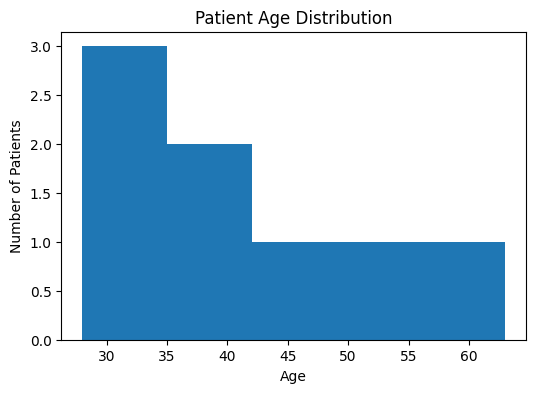

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(df_patients['age'].dropna(), bins=5)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

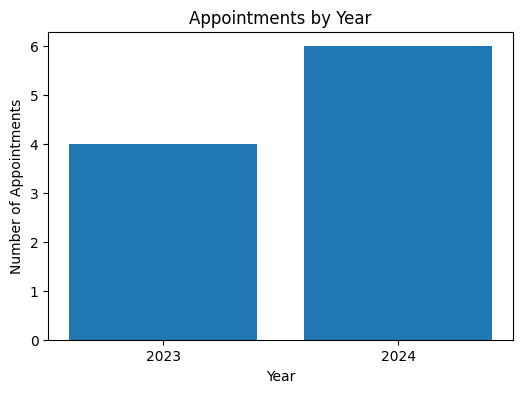

In [22]:
plt.figure(figsize=(6,4))

year_counts = df_dates['year_int'].value_counts().sort_index()

plt.bar(year_counts.index.astype(str), year_counts.values)

plt.title("Appointments by Year")
plt.xlabel("Year")
plt.ylabel("Number of Appointments")

plt.show()

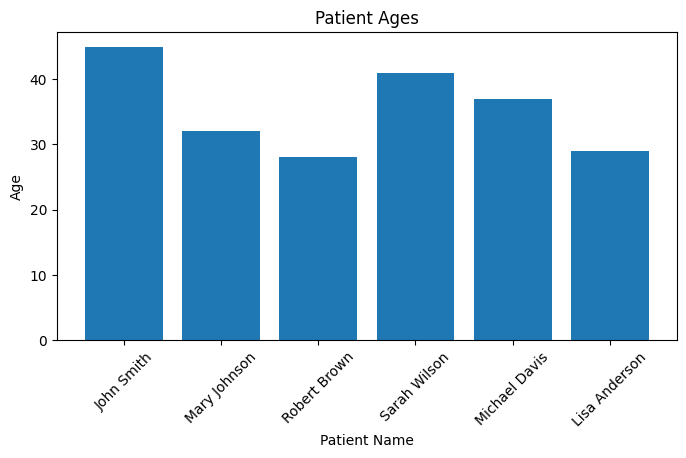

In [24]:
import matplotlib.pyplot as plt

# Remove rows with missing values
df_plot = df_patients.dropna(subset=['patient_name','age'])

plt.figure(figsize=(8,4))

plt.bar(df_plot['patient_name'], df_plot['age'])

plt.title("Patient Ages")
plt.xlabel("Patient Name")
plt.ylabel("Age")

plt.xticks(rotation=45)

plt.show()